## **Предобработка данных**

In [98]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer

Загрузим данные:

In [99]:
df = pd.read_csv('../data/data.csv', sep=';', skip_blank_lines=True)

In [100]:
df

,id,Стадия,Возраст,Способность пациента к ходьбе и бегу,Баллы мускулатуры (верхние конечности),Баллы мускулатуры (нижние конечности),Применение миопатических приемов Говерса при вставании с пола (использование перекаты),Применение миопатических приемов Говерса при вставании с пола (использование опоры),Тест с шестиминутной ходьбой,Приседания,...,Сколиоз (стадии сколиоза по его выраженности),Сколиоз (спутники сколиотической деформации),Кардиомиопатия,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,1.0,6,11.0,Не ходит,3,2,NaN,NaN,NaN,NaN,...,Сколиотическая деформация,NaN,Синусовая тахикардия,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,6,14.0,Не ходит,3,2,NaN,NaN,NaN,NaN,...,NaN,NaN,Синусовая тахикардия,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,3 или 4 [2 или 3],7.0,"Бегает с отрывом двух ног от земли, но без фаз...",4,4,Подъем с пола с переворотом на живот,Подъем с пола с опорой на две руки о пол и бед...,от 350 м до 500 м,Приседает только с использованием приемов Гове...,...,Формирующийся сколиоз,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,6,11.0,Не ходит,3,2,NaN,NaN,NaN,NaN,...,Сколиотическая деформация,Деформация грудной клетки,"Синусовая тахикардия, Дилатационная кардиомиоп...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,6,12.0,Не ходит,2-3,1-2,NaN,NaN,NaN,NaN,...,Сколиотическая деформация,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
790,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Удалим пустые строки и столбцы:

In [101]:
df = df.dropna(axis=0, how='all')
df = df.dropna(axis=1, how='all')

In [102]:
df.shape

(136, 21)

Далее будем работать с каждым признаком постепенно и обрабатывать его:

### **1. Стадия (таргет)**

In [103]:
df['Стадия']

0                      6
1                      6
2      3 или 4 [2 или 3]
3                      6
4                      6
             ...        
131                    2
132                    2
133                    3
134                    4
135                5 [6]
Name: Стадия, Length: 136, dtype: str

In [104]:
df['Стадия'].isna().sum()

np.int64(0)

In [105]:
df['Стадия'].value_counts()

Стадия
6                    38
3                    30
2                    14
4                    11
7                    10
1 [2]                 7
6 [5]                 5
1                     5
5                     5
5 [4]                 3
2 или 3               2
1 [2 или 3]           2
5 [6]                 2
3 или 4 [2 или 3]     1
2 [1]                 1
Name: count, dtype: int64

На данный момент значения представляют собой строковые данные, при этом есть пограничные ситуации, когда точную стадию определить нельзя. Примем упрощения и будем обрабатывать признак следующим образом:

- если при пограничном случае есть значения в $[]$, то берем первое из них

- если скобок нет, например "2 или 3", то берем первое значение

In [106]:
def extraxt_stage_priority(val):
    if pd.isna(val):
        return np.nan
    
    s = str(val)

    #
    match_bracket = re.search(r'\[(\d+)', s)

    if match_bracket:
        return int(match_bracket.group(1))
    
    # 
    match_first = re.search(r'(\d+)', s)
    if match_first:
        return int(match_first.group(1))
    
    return np.nan

In [107]:
df['Стадия'] = df['Стадия'].apply(extraxt_stage_priority)

In [108]:
df['Стадия'].value_counts()

Стадия
6    40
3    30
2    26
4    14
5    10
7    10
1     6
Name: count, dtype: int64

In [109]:
df['Стадия'].dtype

dtype('int64')

(array([ 6., 26., 30., 14., 10., 40., 10.]),
 array([1.        , 1.85714286, 2.71428571, 3.57142857, 4.42857143,
        5.28571429, 6.14285714, 7.        ]),
 <BarContainer object of 7 artists>)

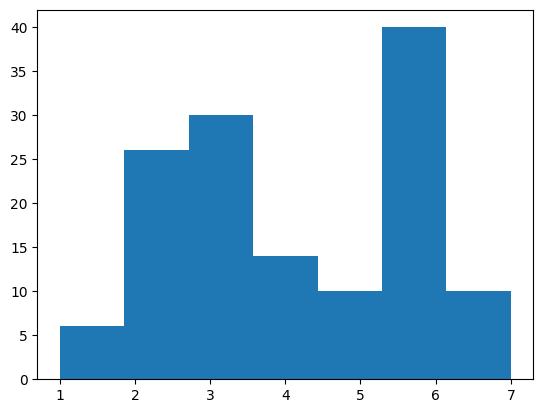

In [110]:
plt.hist(x=df['Стадия'], bins=7)

Также, отметим, что модель принимает таргет в виде [0, ..., 6], а стадии представлены от 1 до 7, поэтому для обучения преобразуем их к верному виду, а на инференсе сделаем обратное преобразование:

In [111]:
df['Стадия'] = df['Стадия'] - 1

In [112]:
df['Стадия'].value_counts()

Стадия
5    40
2    30
1    26
3    14
4    10
6    10
0     6
Name: count, dtype: int64

Как видим таргет корректно обработан, и может быть использован в моделе.

### **2. Возраст**

In [113]:
df['Возраст']

0      11.0
1      14.0
2       7.0
3      11.0
4      12.0
       ... 
131     7.0
132     6.0
133     8.0
134    10.0
135    11.0
Name: Возраст, Length: 136, dtype: float64

In [114]:
df['Возраст'].value_counts()

Возраст
7.0     14
6.0     14
8.0     12
9.0     12
11.0    11
14.0    11
12.0     9
13.0     9
4.0      8
5.0      8
10.0     8
3.0      6
17.0     4
16.0     4
15.0     3
2.0      3
Name: count, dtype: int64

In [115]:
df['Возраст'].dtype

dtype('float64')

In [116]:
df['Возраст'].isna().sum()

np.int64(0)

С возрастом все в порядке, пропусков нет, данные в численном виде. Можем идти дальше.

### **3. Признаки связанные с мобильностью**

В данных присутствует сразу несколько признаков, которые связанны с мобильностью пациента. Есть смысл обработать их вместе.

In [117]:
# Список признаков для анализа
mobility_features = [
    'Тест с шестиминутной ходьбой',
    'Приседания',
    'Подпрыгивания (вверх на 2-х ногах)',
    'Подпрыгивания (вверх на 1-ой ноге)',
    'Ходьба по лестнице (подъем)',
    'Ходьба по лестнице (спуск)'
]

# Словари для всех категориальных признаков (по справочнику v290425)
maps = {
    'Способность пациента к ходьбе и бегу': {
        'Бегает с отрывом двух ног от земли, присутствует фаза полета': 1,
        'Бегает с отрывом двух ног от земли, но без фазы полета': 2,
        'Способность к бегу по типу "Duchenne jog" (напоминает спортивную ходьбу)': 3,
        'Невозможность бега при сохранении ходьбы': 4,
        'Невозможность самостоятельно пройти 10 м': 5,
        'Не ходит': 6
    },
    'Приседания': {
        'Приседает без применения компенсирующих приемов': 1,
        'Приседает с небольшими трудностями (компенсируются приемами Говерса, опирается одной рукой)': 2,
        'Приседает только с использованием приемов Говерса, с опорой на обе руки': 3,
        'Приседает, падая на ягодицы, вставание только с использованием окружающей мебели': 4,
        'Невозможность приседания (навык утерян)': 5
    },
    'Подпрыгивания (вверх на 2-х ногах)': {
        'Прыжок с отрывом двух ног от поверхности пола': 1,
        'Потеря способности к прыжкам при сохранении вставания на носки': 3,
        'Невозможность прыжка, переминается, пытаясь подняться на носки': 4,
        'Невозможность изобразить попытку прыжка': 5
    },
    'Подпрыгивания (вверх на 1-ой ноге)': {
        'Может подпрыгнуть на одной ноге': 1,
        'Подъем на носок без отрыва от поверхности пола': 2,
        'Не может даже подняться на носок, попытка прыжка без отрыва от поверхности пола': 3
    },
    'Ходьба по лестнице (подъем)': {
        'Подъем альтернативным шагом, не нуждаясь в опоре': 1,
        'Подъем приставным шагом без опоры': 2,
        'Подъем приставным шагом, опираясь одной рукой о бедро или о перила': 3,
        'Подъем приставным шагом, держась двумя руками за перила или одной рукой за перила и второй рукой за бедро, подтягивая себя наверх': 4,
        'Невозможность подъема по лестнице': 5
    },
    'Ходьба по лестнице (спуск)': {
        'Спуск альтернативным шагом, не нуждаясь в опоре': 1,
        'Спуск приставным шагом без опоры': 2,
        'Спуск приставным шагом, опираясь одной рукой о бедро или о перила': 3,
        'Спуск приставным шагом, опираясь двумя руками о перила или держась одной рукой за перила и второй рукой за бедро': 4,
        'Невозможность спуска по лестнице': 5
    },
    'Тест с шестиминутной ходьбой': {
        'от 350 м до 500 м': 425.0,
        'от 150 м до 350 м': 250.0,
        '< 10 м': 5.0,
        '> 500 м': 500.0,
        'от 10 м до 150 м': 80.0,
    }
}

In [118]:
for col, mapping in maps.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

Далее необходимо заполнить пропуски в данных, при анализе было замечено, что в случае худших стадий в признаке "Способность к ходьбе и бегу" в последующих признаках, связанные с мобильностью данные пропущены. Поэтому есть мотив, заполнить их худшими значениями, остальные пропуски будут заполнены статистическими данными.

In [119]:
df_analysis = df.copy()

# Создаём таблицу: % пропусков в каждом признаке по группам мобильности
missing_stats = []
for mob_group in [1, 2, 3, 4, 5, 6]:
    subset = df_analysis[df_analysis['Способность пациента к ходьбе и бегу'] == mob_group]
    row = {'mobility_score': mob_group, 'n_patients': len(subset)}
    for col in mobility_features:
        if col in df_analysis.columns:
            row[f'{col}_missing_pct'] = subset[col].isna().mean() * 100
    missing_stats.append(row)

missing_df = pd.DataFrame(missing_stats)
print("Пропуски в признаках по группам мобильности: \n")
print(missing_df.round(1).to_markdown(index=False))

Пропуски в признаках по группам мобильности: 

|   mobility_score |   n_patients |   Тест с шестиминутной ходьбой_missing_pct |   Приседания_missing_pct |   Подпрыгивания (вверх на 2-х ногах)_missing_pct |   Подпрыгивания (вверх на 1-ой ноге)_missing_pct |   Ходьба по лестнице (подъем)_missing_pct |   Ходьба по лестнице (спуск)_missing_pct |
|-----------------:|-------------:|-------------------------------------------:|-------------------------:|-------------------------------------------------:|-------------------------------------------------:|------------------------------------------:|-----------------------------------------:|
|                1 |            6 |                                       50   |                      0   |                                             33.3 |                                             66.7 |                                      33.3 |                                     33.3 |
|                2 |           24 |                           

In [120]:
cols_to_impute = [
    'Способность пациента к ходьбе и бегу',
    'Тест с шестиминутной ходьбой',
    'Приседания',
    'Подпрыгивания (вверх на 2-х ногах)',
    'Подпрыгивания (вверх на 1-ой ноге)',
    'Ходьба по лестнице (подъем)',
    'Ходьба по лестнице (спуск)'
]

# Безопасное приведение к числовому типу (избегаем TypeError)
for col in cols_to_impute:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Векторизованная импутация по клиническим правилам
mask_severe = df['Способность пациента к ходьбе и бегу'] >= 5
mask_moderate = df['Способность пациента к ходьбе и бегу'] == 4

# Стадии 5-6: заполняем худшими значениями только в пропущенных ячейках
severe_imputes = {
    'Тест с шестиминутной ходьбой': 0.0,
    'Ходьба по лестнице (подъем)': 5.0,
    'Ходьба по лестнице (спуск)': 5.0,
    'Подпрыгивания (вверх на 2-х ногах)': 5.0,
    'Подпрыгивания (вверх на 1-ой ноге)': 5.0,
    'Приседания': 5.0
}
for col, val in severe_imputes.items():
    if col in df.columns:
        df.loc[mask_severe & df[col].isna(), col] = val

# Стадия 4: заполняем более мягко (предпоследний балл)
moderate_imputes = {
    'Подпрыгивания (вверх на 2-х ногах)': 4.0,
    'Подпрыгивания (вверх на 1-ой ноге)': 4.0
}

for col, val in moderate_imputes.items():
    if col in df.columns:
        df.loc[mask_moderate & df[col].isna(), col] = val

# Статистическая импутация оставшихся пропусков
for col in cols_to_impute:
    if col in df.columns and df[col].isna().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print("Импутация завершена. Остаток пропусков:")
print(df[cols_to_impute].isna().sum())

Импутация завершена. Остаток пропусков:
Способность пациента к ходьбе и бегу    0
Тест с шестиминутной ходьбой            0
Приседания                              0
Подпрыгивания (вверх на 2-х ногах)      0
Подпрыгивания (вверх на 1-ой ноге)      0
Ходьба по лестнице (подъем)             0
Ходьба по лестнице (спуск)              0
dtype: int64


### **4. Баллы мускулатуры**

In [121]:
cols_muscle = ['Баллы мускулатуры (верхние конечности)', 'Баллы мускулатуры (нижние конечности)']

In [122]:
df[cols_muscle].value_counts()

Баллы мускулатуры (верхние конечности)  Баллы мускулатуры (нижние конечности)
4                                       4                                        13
3-4                                     3-4                                      12
3                                       3                                        10
                                        2                                         8
4                                       3                                         7
2-3                                     2-3                                       5
2                                       2                                         3
3                                       2-3                                       3
1-2                                     0-1                                       3
                                        1                                         3
3,5                                     3                                         

In [123]:
df[cols_muscle].isna().sum()

Баллы мускулатуры (верхние конечности)    16
Баллы мускулатуры (нижние конечности)     38
dtype: int64

Преобразуем диапазоны (например, "2-3" или "3,5-4") в среднее числовое значение.

In [124]:
def parse_muscle_score(val):
    """
    Преобразует '2-3' -> 2.5, '3,5-4' -> 3.75, '4' -> 4.0
    """
    if pd.isna(val):
        return np.nan
    
    s = str(val).strip().replace(',', '.')
    if '-' in s:
        try:
            parts = s.split('-')
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return np.nan
    else:
        try:
            return float(s)
        except ValueError:
            return np.nan

In [125]:
for col in cols_muscle:
    df[col] = df[col].apply(parse_muscle_score)
    median_val = df[col].median() # пропуски заполняем медианой
    df[col] = df[col].fillna(median_val)

In [126]:
df[cols_muscle].isna().sum()

Баллы мускулатуры (верхние конечности)    0
Баллы мускулатуры (нижние конечности)     0
dtype: int64

### **5. Приемы Говерса**

In [127]:
cols_gowers = [
    'Применение миопатических приемов Говерса при вставании с пола (использование опоры)',
    'Применение миопатических приемов Говерса при вставании с пола (использование перекаты)'
]

In [128]:
df[cols_gowers].value_counts()

Применение миопатических приемов Говерса при вставании с пола (использование опоры)  Применение миопатических приемов Говерса при вставании с пола (использование перекаты)
Подъем с пола с опорой на две руки о пол и бедра, "взбираясь по себе"                Подъем с пола с переворотом на живот                                                      22
Подъем с пола с опорой на одну руку о пол или о бедро                                Подъем с пола с перекатом                                                                 17
Подъем с пола с использованием окружающей мебели при вставании                       Подъем с пола с переворотом на живот                                                       4
Подъем с пола с опорой на одну руку о пол или о бедро                                Подъем с пола с переворотом на живот                                                       2
Подъем с пола с опорой на две руки о пол и бедра, "взбираясь по себе"                Подъем с пола с перекатом      

In [129]:
df[cols_gowers].isna().sum()

Применение миопатических приемов Говерса при вставании с пола (использование опоры)       63
Применение миопатических приемов Говерса при вставании с пола (использование перекаты)    83
dtype: int64

Закодируем текстовые описания в числа (Ordinal Encoding) от 1 (легко) до 5 (невозможно), основываясь на справочнике v290425.

In [130]:
# А. Использование перекатов
map_rolls = {
    'Подъем с пола без переката': 1,
    'Подъем с пола с перекатом': 2,
    'Подъем с пола с переворотом на живот': 3,
}

# Б. Использование опоры
map_support = {
    'Подъем с пола без опоры': 1,
    'Подъем с пола с опорой на одну руку о пол или о бедро': 2,
    'Подъем с пола с опорой на одну руку о пол': 2,
    'Подъем с пола с опорой на две руки о пол и бедра, "взбираясь по себе"': 3,
    'Подъем с пола с опорой на две руки о пол и бёдра, "взбираясь по себе"': 3,
    'Подъем с пола с использованием окружающей мебели при вставании': 4,
    'Утрата навыка подъема на ноги': 5
}

In [131]:
df[cols_gowers[1]] = df[cols_gowers[1]].map(map_rolls)
df[cols_gowers[0]] = df[cols_gowers[0]].map(map_support)

Пропуски заполняем медианой:

In [132]:
for col in cols_gowers:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

### **6. Тугоподвижность и контрактуры**

Это мультилейбл признак. В одной ячейке может быть записано сразу несколько проблем (например, "Контрактуры голеностопных, Контрактуры коленных"). Модели не умеют читать такие списки текстом, поэтому мы разобьём это на отдельные бинарные колонки (0/1) для каждого сустава.

In [133]:
def parse_multilabel(val):
    if pd.isna(val) or str(val).strip() == '':
        return []
    return [x.strip() for x in str(val).split(',') if x.strip()]

In [134]:
# Полный список возможных значений согласно справочнику
ALL_CONTRACTURES = [
    'Тугоподвижность голеностопных суставов',
    'Контрактуры голеностопных суставов',
    'Тугоподвижность тазобедренных суставов',
    'Контрактуры тазобедренных суставов',
    'Тугоподвижность коленных суставов',
    'Контрактуры коленных суставов',
    'Тугоподвижность лучезапястных суставов',
    'Контрактуры лучезапястных суставов',
    'Тугоподвижность локтевых суставов',
    'Контрактуры локтевых суставов',
    'Контрактуры нижнечелюстно-височных суставов'
]

# Парсим ячейки в списки
contractures_lists = df['Тугоподвижность и контрактуры (нарушения суставной подвижности)'].apply(parse_multilabel)

# Инициализируем Binarizer с явным списком и регистрируем классы
mlb_contractures = MultiLabelBinarizer(classes=ALL_CONTRACTURES)
mlb_contractures.fit([[]]) 

# Трансформируем данные
contractures_bin = pd.DataFrame(
    mlb_contractures.transform(contractures_lists),
    columns=[col for col in mlb_contractures.classes_],
    index=df.index
)

# Присоединяем и удаляем исходную текстовую колонку
df = pd.concat([df, contractures_bin], axis=1)
df.drop(columns=['Тугоподвижность и контрактуры (нарушения суставной подвижности)'], inplace=True)

### **7. Особенности позы пациента: функция рук и положение**

Эти два признака отражают прогрессирование ограничений из-за контрактур и слабости мышц. 
В CSV встречаются артефакты экранирования кавычек (`""""сидя""""`), которые нужно предварительно очистить.

In [135]:
pose_features = [
    'Особенности позы пациента, обусловленные контрактурами (положение пациента)',
    'Особенности позы пациента, обусловленные контрактурами (функциональные нарушения верхней конечности)',
]

print(df[pose_features[0]].value_counts()) 
print()
print(df[pose_features[1]].value_counts())

Особенности позы пациента, обусловленные контрактурами (положение пациента)
Пациент в позе "сидя" (коленные суставы под углом более 90 градусов), Сидячий пациент может быть поставлен на ноги с помощью опоры для стояния        27
"Пациент в позе ""сидя"" (коленные суставы под углом более 90 градусов)", Сидячий пациент может быть поставлен на ноги с помощью опоры для стояния    10
Пациент в позе "сидя" (коленные суставы под углом более 90 градусов)                                                                                   6
"Пациент в позе ""сидя"" (коленные суставы под углом более 90 градусов)", Пациента невозможно поставить в вертикальное положение                       3
Сидячий пациент может быть поставлен на ноги с помощью опоры для стояния, Пациент в позе "сидя" (коленные суставы под углом более 90 градусов)         1
Пациента невозможно поставить в вертикальное положение, Пациент в позе "сидя" (коленные суставы под углом более 90 градусов)                           1
"Пацие

In [136]:
upper_limbs_map = {
    'Пациент может поднять руки выше уровня плеч': 1,
    'Пациент может поднять руки не выше уровня плеч': 2,
    'Пациент не может поднять руки': 3
}

pos_severity_map = {
    'Пациент в позе "сидя" (коленные суставы под углом более 90 градусов)': 1,
    'Сидячий пациент может быть поставлен на ноги с помощью опоры для стояния': 1,
    'Пациент в позе "лежа" (коленные суставы под углом менее 90 градусов)': 2,
    'Пациента невозможно поставить в вертикальное положение': 2
}

In [137]:
# Функция парсинга
def clean_position(val):
    if pd.isna(val) or str(val).strip() == '':
        return []
    s = str(val).replace('""', '"').strip()
    return [x.strip().strip('"') for x in s.split(',') if x.strip().strip('"')]

positions_list = df[pose_features[0]].apply(clean_position)

# Функция оценки
def get_worst_position(pos_list):
    if not pos_list:
        return 1

    if isinstance(pos_list, str):
        return pos_severity_map.get(pos_list, 1)
        
    severities = [pos_severity_map.get(p, 1) for p in pos_list]
    return max(severities)

df[pose_features[0]] = positions_list.apply(get_worst_position)
df[pose_features[0]] = df[pose_features[0]].fillna(1).astype(float)

df[pose_features[1]] = df[pose_features[1]].map(upper_limbs_map)
df[pose_features[1]] = df[pose_features[1]].fillna(1).astype(float)

In [138]:
df[pose_features].isna().sum()

Особенности позы пациента, обусловленные контрактурами (положение пациента)                             0
Особенности позы пациента, обусловленные контрактурами (функциональные нарушения верхней конечности)    0
dtype: int64

### **8. Гиперлордоз, Сколиоз и Кардиомиопатия**

Последние этапы очистки:

1. **Гиперлордоз**: Ординарное кодирование (нет -> небольшой -> умеренный -> выраженный).

2. **Сколиоз**: 
   - Стадия: Ординарное кодирование.
   - Спутники: Ординарное кодирование.
   
   Пропуски в обоих признаках заполняем 0 → интерпретируем как "нет сколиоза/спутников"


3. **Кардиомиопатия**: `MultiLabelBinarizer` (разбиваем проявления на бинарные признаки).

In [139]:
hyperlordosis_map = {
    'Небольшой гиперлордоз при вертикализации': 2,
    'Умеренный гиперлордоз при вертикализации': 3,
    'Выраженный гиперлордоз при вертикализации': 4
}

# Пропуски считаем нормой (нет гиперлордоза) -> 1
df['Гиперлордоз'] = df['Гиперлордоз'].map(hyperlordosis_map).fillna(0)
df['Гиперлордоз'] = df['Гиперлордоз'].astype(int)

In [140]:
scoliosis_features = [
    'Сколиоз (стадии сколиоза по его выраженности)',
    'Сколиоз (спутники сколиотической деформации)',
]

scoliosis_map = {
    'Сколиоз (стадии сколиоза по его выраженности)': {
        'Формирующийся сколиоз': 2,
        'Сколиотическая деформация': 4
    },
    'Сколиоз (спутники сколиотической деформации)': {
        'Деформация грудной клетки': 1,
        'Деформация таза': 2
    },
}

df[scoliosis_features[0]] = df[scoliosis_features[0]].map(scoliosis_map['Сколиоз (стадии сколиоза по его выраженности)']).fillna(0).astype(int)
df[scoliosis_features[1]] = df[scoliosis_features[1]].map(scoliosis_map['Сколиоз (спутники сколиотической деформации)']).fillna(0).astype(int)

print(df[scoliosis_features[0]].value_counts()); print()
print(df[scoliosis_features[1]].value_counts()); print()
print(df[scoliosis_features].isna().sum())

Сколиоз (стадии сколиоза по его выраженности)
4    69
0    59
2     8
Name: count, dtype: int64

Сколиоз (спутники сколиотической деформации)
0    114
1     21
2      1
Name: count, dtype: int64

Сколиоз (стадии сколиоза по его выраженности)    0
Сколиоз (спутники сколиотической деформации)     0
dtype: int64


In [141]:
# Определи все возможные значения из справочников
ALL_CARDIO = [
    'Синусовая тахикардия',
    'Повышение АД',
    'Нормальное АД',
    'Нестабильное АД (сниженное/нормальное АД/повышенное)',
    'Дилатационная кардиомиопатия',
    'Снижение глобальной сократительной способности миокарда',
    'Снижение фракции выброса',
    'Отеки / Сердечная недостаточность'
]

# binarizer
mlb_cardio = MultiLabelBinarizer(classes=ALL_CARDIO)
mlb_cardio.fit([[]])  # регистрируем классы

# Примени transform
cardio_lists = df['Кардиомиопатия'].apply(parse_multilabel)
cardio_bin = pd.DataFrame(
    mlb_cardio.transform(cardio_lists),
    columns=[c for c in mlb_cardio.classes_],
    index=df.index
)
df = pd.concat([df, cardio_bin], axis=1)

# Удалим исходную колонку
df.drop(columns=['Кардиомиопатия'], inplace=True)

In [142]:
df.columns

Index(['id', 'Стадия', 'Возраст', 'Способность пациента к ходьбе и бегу',
       'Баллы мускулатуры (верхние конечности)',
       'Баллы мускулатуры (нижние конечности)',
       'Применение миопатических приемов Говерса при вставании с пола (использование перекаты)',
       'Применение миопатических приемов Говерса при вставании с пола (использование опоры)',
       'Тест с шестиминутной ходьбой', 'Приседания',
       'Подпрыгивания (вверх на 2-х ногах)',
       'Подпрыгивания (вверх на 1-ой ноге)', 'Ходьба по лестнице (подъем)',
       'Ходьба по лестнице (спуск)',
       'Особенности позы пациента, обусловленные контрактурами (функциональные нарушения верхней конечности)',
       'Особенности позы пациента, обусловленные контрактурами (положение пациента)',
       'Гиперлордоз', 'Сколиоз (стадии сколиоза по его выраженности)',
       'Сколиоз (спутники сколиотической деформации)',
       'Тугоподвижность голеностопных суставов',
       'Контрактуры голеностопных суставов',
       'Ту

In [143]:
df.isna().sum()

id                                                                                                      0
Стадия                                                                                                  0
Возраст                                                                                                 0
Способность пациента к ходьбе и бегу                                                                    0
Баллы мускулатуры (верхние конечности)                                                                  0
Баллы мускулатуры (нижние конечности)                                                                   0
Применение миопатических приемов Говерса при вставании с пола (использование перекаты)                  0
Применение миопатических приемов Говерса при вставании с пола (использование опоры)                     0
Тест с шестиминутной ходьбой                                                                            0
Приседания                                    

In [144]:
df.to_csv('../data/clean_data.csv', index=False, encoding='utf-8')